# Non-reversible ISOKANN targets — benchmark

Two rough ideas for **non-reversible isotargets** (`schur_isotargets.py`, vendored here; canonical
copy in `examples/non_reversible/`) extend the reversible **ISA** inner-simplex transform to
directional / cyclic transfer operators, where a complex-conjugate eigenpair can sit in the
dominant invariant subspace:

| variant | what it adds over ISA |
|---|---|
| **Schur-ISA** (`TransformSchurISA`) | ordered real **Schur** basis (never splits a 2×2 complex block) + a **feasibility projection** that pushes the inner-simplex memberships non-negative |
| **GPCCA** (`TransformGPCCA`) | feasibility **+** a Röblitz–Weber **crispness** reward (sharper memberships) |

Both reduce **exactly to ISA** when the dominant top-k spectrum is real, so they should be *no worse*
on reversible systems and *better-diagnosed* on cyclic ones.

**This notebook benchmarks them, adjusted to the existing AMORE isotarget pipeline, against three
reversible baselines (ISA, GramSchmidt, SVD-Power) on three systems:**

| system | type | data | scoring |
|---|---|---|---|
| `triple_well` | reversible | benchmark_v3 (2D triple-well) | Hungarian \|r\| of χ vs FEM committors `p_A,p_B,p_C` |
| `adp_300k_0p1` | reversible | benchmark_v4 (vacuum alanine dipeptide, **300 K, τ=0.1 ps**, 231 distances, **25k anchors / 2500 iters, 1200-iter committor warm-up**, v4-faithful) | Hungarian \|r\| of χ vs 0.1 ps transfer-operator EV2 (φ), EV3 (ψ) |
| `directed_ring` | **non-reversible** | new toy: 3-well ring + non-conservative drift | **cr2-style**: Hungarian **fate AUROC** of χ vs basin labels, Spearman, + cyclic feasibility diagnostics |

**Warm-up.** The simplex-based variants (ISA, Schur-ISA, GPCCA) use the **1-D ShiftScale committor
warm-up** of `cr2_benchmark` / benchmark_v4's `ssm_isa`: train a genuine `k=1` ShiftScale ISOKANN
coordinate, then seed every output row of the k-D net from it (`init_from_warmup`) so ISA deflation
starts from the dominant slow mode — run long enough to *converge* the committor (100 iters suffices for the 2-D systems; the 231-D ADP committor needs ~1200, see §5). GramSchmidt is its own target (no warm-up); SVD-Power is power
iteration.

Pipeline adjustments to wire the rough ideas in (see `nonrev_targets.py`): (1) (k,n)↔(n,k)
transpose; (2) `simplex_normalize=False` — return the feasibility-projected target in ISA-like
*natural scale* (the hard probability-simplex normalization squashes a linear ChiNet to the
centroid); (3) reset the cross-iteration warm-start `A_prev` each call — in the AMORE fixed-point
loop χ itself moves every step, so a persistent warm-start drifts the membership matrix into
collapse. Network, optimizer, plateau stop and best-on-val checkpoint are identical to
benchmark_v3/v4.

In [1]:
import os, sys, json, glob
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, Image, display

HERE = os.path.abspath("")
sys.path.insert(0, HERE)
import toy_systems as ts
import train_eval as te

np.set_printoptions(precision=3, suppress=True)
N_SEEDS = 3
VARIANTS = te.VARIANTS
LABELS = te.LABELS
print("variants:", VARIANTS)

C:\Users\kr3ss\miniforge3\envs\amore\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


variants: ['isa', 'gramschmidt', 'svd_power', 'schurisa', 'gpcca']


## 1. The three systems

The new **directed-ring** toy is overdamped Langevin on a 3-well ring potential
$U=a(r-R)^2+b\cos 3\theta$ **plus a tangential, non-conservative drift** $\kappa\,(-y,x)/r$.
With $\kappa>0$ detailed balance is broken: a probability current circulates A→B→C→A and the
dominant transfer-operator subspace carries a **complex-conjugate pair** — the regime the
reversible inner-simplex was never built for.

In [2]:
ring = ts.simulate_directed_ring(n_anchors=2500, K=8, burst=250)
tw   = ts.load_triple_well()
adp  = ts.load_adp_300k_0p1(max_anchors=25000)
SYSTEMS = {"directed_ring": ring, "triple_well": tw, "adp_300k_0p1": adp}
for tag, s in SYSTEMS.items():
    print(f"{tag:14s} reversible={s['reversible']!s:5s} N={len(s['feat']):6d} F={s['feat'].shape[1]:3d} "
          f"labels={'yes' if s['labels'] is not None else 'no'}")
print("\nring 3-state transfer operator eigenvalues:", np.round(ring['eigs'], 4))
print("ring max |Im(λ)| =", round(np.abs(ring['eigs'].imag).max(), 4), " => complex pair => non-reversible")

directed_ring  reversible=False N=  2500 F=  2 labels=yes
triple_well    reversible=True  N=  1600 F=  2 labels=no
adp_300k_0p1   reversible=True  N= 25000 F=231 labels=no

ring 3-state transfer operator eigenvalues: [1.   +0.j    0.895+0.057j 0.895-0.057j]
ring max |Im(λ)| = 0.0574  => complex pair => non-reversible


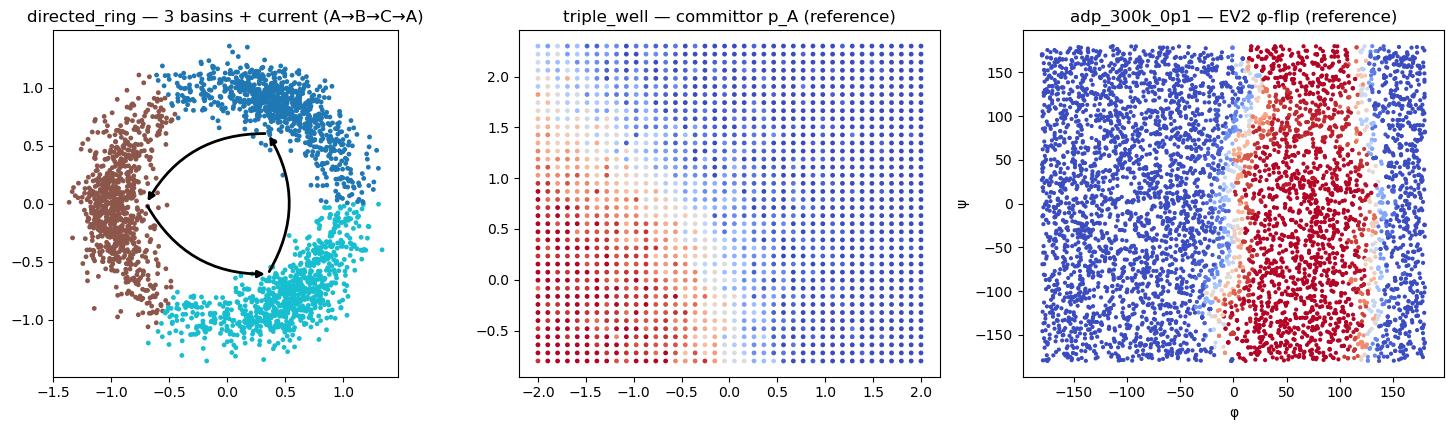

In [3]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.4))
sc = ax[0].scatter(ring['coords'][:,0], ring['coords'][:,1], c=ring['labels'], s=6, cmap='tab10')
cen = np.array([[np.cos(t), np.sin(t)] for t in [np.pi/3, np.pi, 5*np.pi/3]])
for i in range(3):
    j = (i+1) % 3
    ax[0].annotate("", xy=cen[j]*0.7, xytext=cen[i]*0.7,
                   arrowprops=dict(arrowstyle="-|>", color="k", lw=2, connectionstyle="arc3,rad=0.3"))
ax[0].set_title("directed_ring — 3 basins + current (A→B→C→A)"); ax[0].set_aspect('equal')
ax[1].scatter(tw['coords'][:,0], tw['coords'][:,1], c=tw['refs'][0], s=6, cmap='coolwarm')
ax[1].set_title("triple_well — committor p_A (reference)")
ss = np.random.default_rng(0).choice(len(adp['coords']), 6000, replace=False)
ax[2].scatter(adp['coords'][ss,0]*180/np.pi, adp['coords'][ss,1]*180/np.pi, c=adp['refs'][0][ss], s=4, cmap='coolwarm')
ax[2].set_title("adp_300k_0p1 — EV2 φ-flip (reference)"); ax[2].set_xlabel("φ"); ax[2].set_ylabel("ψ")
plt.tight_layout(); plt.show()

## 2. Train all variants × systems × seeds

`train_chi` caches each run under `runs/`, so this is fast on re-run (and was pre-populated by
`run_benchmark.py`). The ISA family first trains a **1-D ShiftScale committor** then seeds the k-D
net from it (`init_from_warmup`) before the variant's isotarget loop; GramSchmidt is its own target;
SVD-Power is subspace power iteration.

In [4]:
from run_benchmark import RingCfg, TWCfg, ADPCfg
CFG = {"directed_ring": RingCfg, "triple_well": TWCfg, "adp_300k_0p1": ADPCfg}

RES = {}   # RES[tag][variant] = list over seeds of result dicts
for tag, system in SYSTEMS.items():
    RES[tag] = {}
    for v in VARIANTS:
        RES[tag][v] = [te.train_chi(system, v, s, cfg=CFG[tag], verbose=False) for s in range(N_SEEDS)]
print("loaded", sum(len(RES[t][v]) for t in RES for v in RES[t]), "runs")

loaded 45 runs


In [5]:
# scoring helpers over seeds (score the best-on-validation chi_best)
def agg_shape(tag, v):
    rs = [te.shape_r(r['chi_best'], SYSTEMS[tag]['refs'])[0] for r in RES[tag][v]]
    return np.nanmean(rs), np.nanstd(rs)
def agg_maxr(tag, v, ref_idx):
    refs = SYSTEMS[tag]['refs']
    rs = [max(abs(te.pearson_r(r['chi_best'][:,j], refs[ref_idx])) for j in range(3)) for r in RES[tag][v]]
    return np.nanmean(rs)
def agg_keff(tag, v):
    return np.nanmean([int((r['chi_best'].std(0) > 0.05).sum()) for r in RES[tag][v]])
def agg_auroc(tag, v):
    labels = SYSTEMS[tag]['labels']
    rs = [te.fate_auroc(r['chi_best'], labels)[0] for r in RES[tag][v]]
    return np.nanmean(rs), np.nanstd(rs)
def agg_spear(tag, v):
    return np.nanmean([te.fate_spearman(r['chi_best'], SYSTEMS[tag]['refs']) for r in RES[tag][v]])
print("scoring helpers ready")

scoring helpers ready


## 3. Reversible toys (benchmark_v3 / v4 style)

Shape score = Hungarian-matched mean |Pearson r| of the 3 χ vs the reference functions, with the
per-reference best |r| and k_eff (modes with SD>0.05) alongside.

In [6]:
def reversible_table(tag, ref_labels):
    rows = ["| Method | Hungarian \\|r\\| | " + " | ".join(f"max\\|r\\| {n}" for n in ref_labels) + " | k_eff |",
            "|---|---|" + "---|"*len(ref_labels) + "---|"]
    for v in VARIANTS:
        m, sd = agg_shape(tag, v)
        maxs = " | ".join(f"{agg_maxr(tag, v, i):.3f}" for i in range(len(ref_labels)))
        rows.append(f"| {LABELS[v]} | {m:.3f} ±{sd:.3f} | {maxs} | {agg_keff(tag, v):.1f} |")
    return "\n".join(rows)

display(Markdown("### triple_well — reference: FEM committors p_A, p_B, p_C\n\n"
                 + reversible_table("triple_well", ["p_A", "p_B", "p_C"])))
display(Markdown("### adp_300k_0p1 — reference: 0.1 ps transfer-operator EV2 (φ), EV3 (ψ)\n\n"
                 + reversible_table("adp_300k_0p1", ["φ", "ψ"])))

### triple_well — reference: FEM committors p_A, p_B, p_C

| Method | Hungarian \|r\| | max\|r\| p_A | max\|r\| p_B | max\|r\| p_C | k_eff |
|---|---|---|---|---|---|
| ISA (reversible) | 0.972 ±0.010 | 0.973 | 0.979 | 0.964 | 3.0 |
| GramSchmidt (reversible) | 0.884 ±0.019 | 0.876 | 0.871 | 0.974 | 2.0 |
| SVD-Power (reversible) | 0.698 ±0.104 | 0.841 | 0.890 | 0.965 | 2.0 |
| Schur-ISA (non-rev) | 0.763 ±0.157 | 0.808 | 0.905 | 0.676 | 2.0 |
| GPCCA (non-rev) | 0.792 ±0.105 | 0.853 | 0.923 | 0.647 | 2.7 |

### adp_300k_0p1 — reference: 0.1 ps transfer-operator EV2 (φ), EV3 (ψ)

| Method | Hungarian \|r\| | max\|r\| φ | max\|r\| ψ | k_eff |
|---|---|---|---|---|
| ISA (reversible) | 0.519 ±0.016 | 0.883 | 0.184 | 3.0 |
| GramSchmidt (reversible) | 0.928 ±0.020 | 0.960 | 0.896 | 3.0 |
| SVD-Power (reversible) | 0.503 ±0.046 | 0.439 | 0.633 | 1.7 |
| Schur-ISA (non-rev) | 0.471 ±0.106 | 0.436 | 0.506 | 1.0 |
| GPCCA (non-rev) | 0.541 ±0.077 | 0.634 | 0.451 | 0.0 |

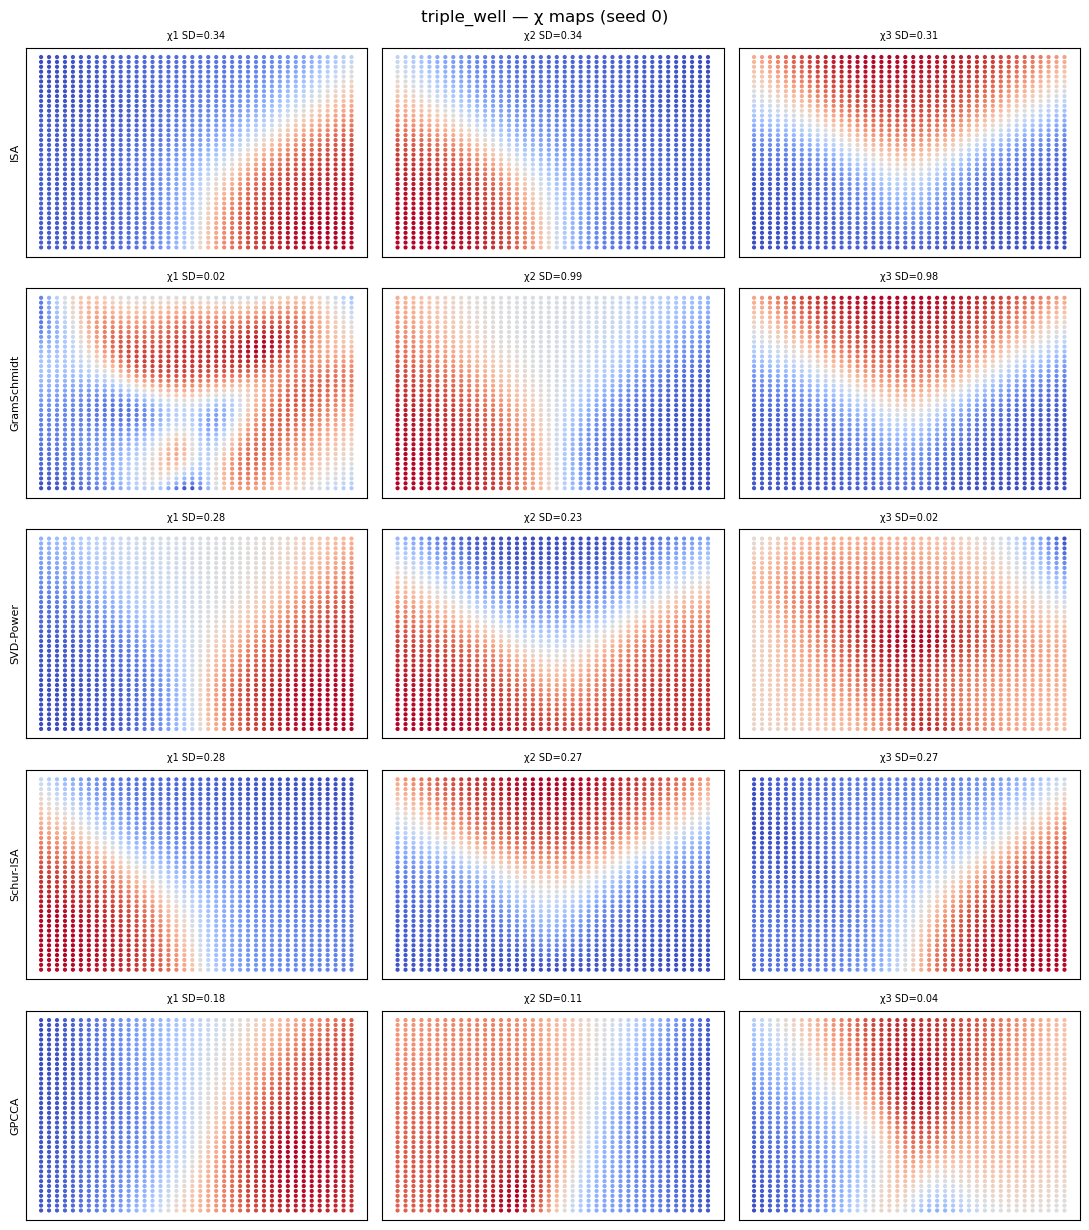

In [7]:
def chi_panels(tag, project=None, title=""):
    coords = SYSTEMS[tag]['coords']
    if project == "deg": coords = coords*180/np.pi
    fig, ax = plt.subplots(len(VARIANTS), 3, figsize=(11, 2.5*len(VARIANTS)))
    for r, v in enumerate(VARIANTS):
        chi = RES[tag][v][0]['chi_best']
        for j in range(3):
            a = ax[r, j]
            a.scatter(coords[:,0], coords[:,1], c=chi[:,j], s=4, cmap='coolwarm')
            a.set_xticks([]); a.set_yticks([])
            if j == 0: a.set_ylabel(LABELS[v].split(" (")[0], fontsize=8)
            a.set_title(f"χ{j+1} SD={chi[:,j].std():.2f}", fontsize=7)
    fig.suptitle(title); plt.tight_layout(); plt.show()

chi_panels("triple_well", title="triple_well — χ maps (seed 0)")

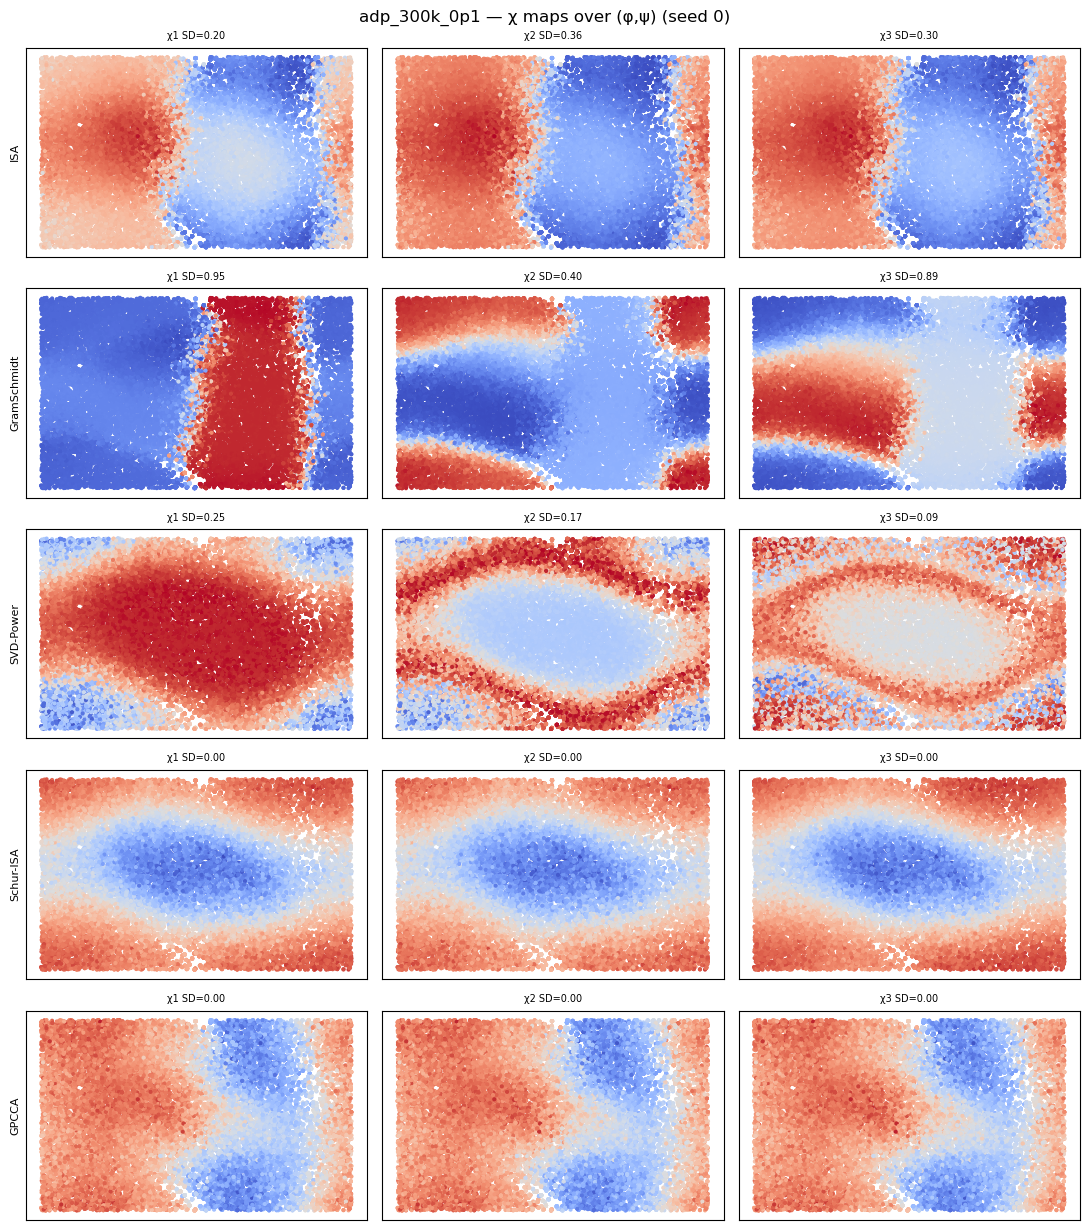

In [8]:
chi_panels("adp_300k_0p1", project="deg", title="adp_300k_0p1 — χ maps over (φ,ψ) (seed 0)")

## 4. Non-reversible ring (cr2_benchmark style)

The ring has no committor reference, so χ-map quality is scored as in `cr2_benchmark`: **Hungarian
fate AUROC** of the 3 χ against the 3 basin labels (one-vs-rest), plus Spearman and the Hungarian
\|r\| vs the dominant complex eigenvector's (Re, Im) ≈ (cos, sin) ring shapes.

In [9]:
rows = ["| Method | fate AUROC (Hung.) | Spearman | shape \\|r\\| (Re,Im v2) | k_eff |",
        "|---|---|---|---|---|"]
for v in VARIANTS:
    au, ausd = agg_auroc("directed_ring", v)
    sp = agg_spear("directed_ring", v)
    sh, _ = agg_shape("directed_ring", v)
    rows.append(f"| {LABELS[v]} | {au:.3f} ±{ausd:.3f} | {sp:.3f} | {sh:.3f} | {agg_keff('directed_ring', v):.1f} |")
display(Markdown("### directed_ring — χ-map quality\n\n" + "\n".join(rows)))

### directed_ring — χ-map quality

| Method | fate AUROC (Hung.) | Spearman | shape \|r\| (Re,Im v2) | k_eff |
|---|---|---|---|---|
| ISA (reversible) | 0.997 ±0.000 | 0.896 | 0.904 | 3.0 |
| GramSchmidt (reversible) | 0.737 ±0.064 | 0.764 | 0.928 | 3.0 |
| SVD-Power (reversible) | 0.820 ±0.136 | 0.801 | 0.881 | 2.0 |
| Schur-ISA (non-rev) | 0.911 ±0.122 | 0.801 | 0.828 | 2.3 |
| GPCCA (non-rev) | 0.953 ±0.061 | 0.715 | 0.746 | 2.7 |

### Cyclic feasibility diagnostics — the point of the non-reversible targets

The Schur transforms log, every iteration: the **imaginary part** of the coarse-propagator spectrum
(>0 ⇒ a cycle the reversible methods cannot see), the **most-negative inner-simplex membership
*before* projection** (this is exactly what *plain ISA* would emit — negative ⇒ infeasible /
"silently wrong"), the membership **after** the feasibility projection, and **cond(A)**.

In [10]:
def diag_summary(v):
    D = [r['diag'] for r in RES["directed_ring"][v] if r['diag'].shape[0]]
    if not D: return None
    D = np.vstack(D)
    cyc = D[D[:,1] > 0.01]
    peak_imag = float(np.nanmax(D[:,1]))
    if cyc.shape[0] == 0: cyc = D
    return peak_imag, float(np.nanmean(cyc[:,2])), float(np.nanmean(cyc[:,3])), float(np.nanmedian(cyc[:,4]))

rows = ["| Method | peak max\\|Im λ\\| | plain-ISA min membership (before) | after projection | cond(A) |",
        "|---|---|---|---|---|"]
for v in ["schurisa", "gpcca"]:
    s = diag_summary(v)
    if s is None: rows.append(f"| {LABELS[v]} | — | — | — | — |"); continue
    rows.append(f"| {LABELS[v]} | {s[0]:.3f} | {s[1]:+.3f} | {s[2]:+.3f} | {s[3]:.2g} |")
display(Markdown("\n".join(rows)))
display(Markdown(
    "- **peak max|Im λ| > 0** confirms the dominant coarse propagator carries a complex pair on the ring "
    "(it stays ≈0 on the reversible toys).\n"
    "- **plain-ISA min membership < 0**: the reversible inner simplex assigns *negative* memberships "
    "(a triangle cannot tile a circle) — it 'works' for shape correlation but the implied state "
    "decomposition is infeasible.\n"
    "- **after projection ≈ 0**: the feasibility step repairs it."))

| Method | peak max\|Im λ\| | plain-ISA min membership (before) | after projection | cond(A) |
|---|---|---|---|---|
| Schur-ISA (non-rev) | 0.264 | -0.239 | -0.001 | 29 |
| GPCCA (non-rev) | 0.256 | -0.288 | -0.269 | 22 |

- **peak max|Im λ| > 0** confirms the dominant coarse propagator carries a complex pair on the ring (it stays ≈0 on the reversible toys).
- **plain-ISA min membership < 0**: the reversible inner simplex assigns *negative* memberships (a triangle cannot tile a circle) — it 'works' for shape correlation but the implied state decomposition is infeasible.
- **after projection ≈ 0**: the feasibility step repairs it.

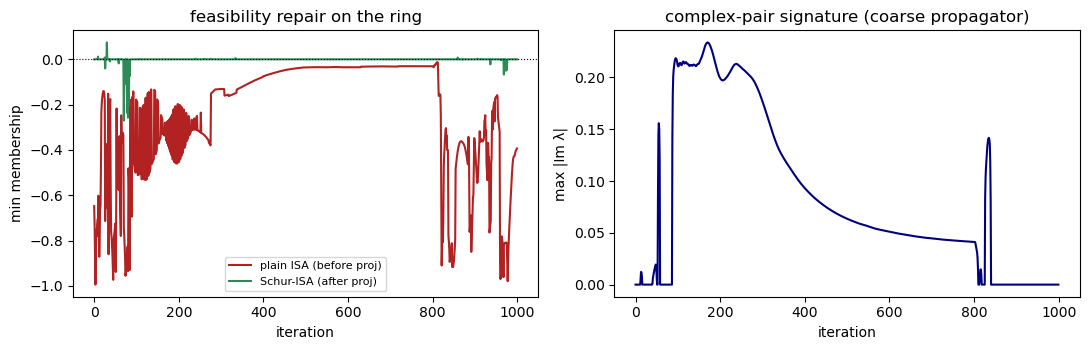

In [11]:
sd_pick = max(range(N_SEEDS), key=lambda s: int((RES["directed_ring"]["schurisa"][s]['chi_best'].std(0) > 0.05).sum()))
d = RES["directed_ring"]["schurisa"][sd_pick]['diag']
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
if d.shape[0]:
    ax[0].plot(d[:,0], d[:,2], label="plain ISA (before proj)", color="firebrick")
    ax[0].plot(d[:,0], d[:,3], label="Schur-ISA (after proj)", color="seagreen")
    ax[0].axhline(0, color="k", lw=0.8, ls=":")
    ax[0].set_xlabel("iteration"); ax[0].set_ylabel("min membership")
    ax[0].set_title("feasibility repair on the ring"); ax[0].legend(fontsize=8)
    ax[1].plot(d[:,0], d[:,1], color="navy"); ax[1].set_xlabel("iteration")
    ax[1].set_ylabel("max |Im λ|"); ax[1].set_title("complex-pair signature (coarse propagator)")
plt.tight_layout(); plt.show()

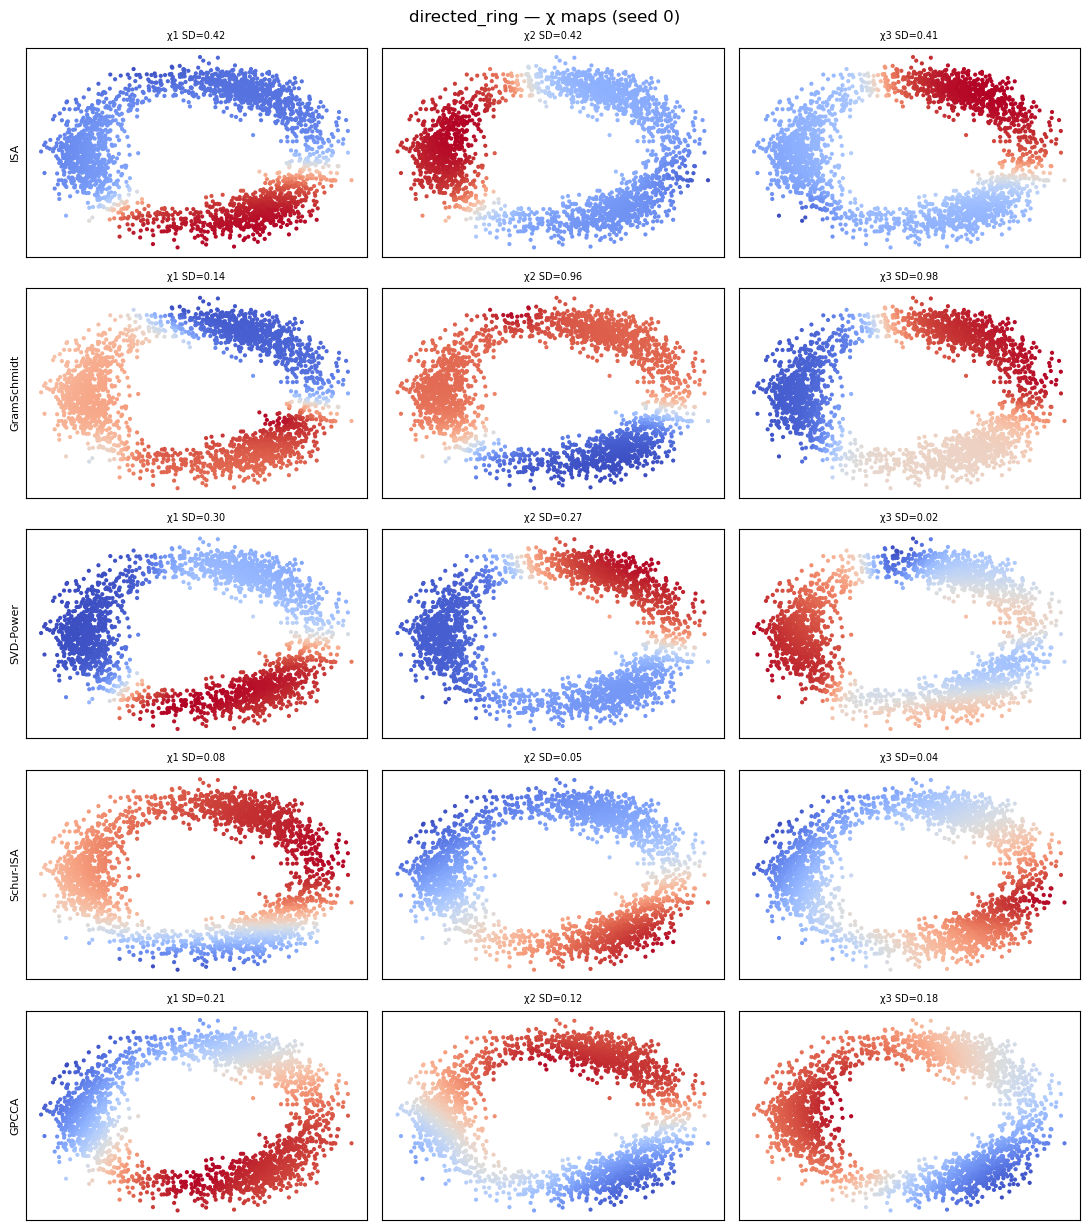

In [12]:
chi_panels("directed_ring", title="directed_ring — χ maps (seed 0)")

## 5. Findings

**The 1-D ShiftScale committor warm-up sharply improves the whole ISA family.** Seeding the k-D net
from a converged 1-D ShiftScale committor (the cr2_benchmark / v4-`ssm_isa` warm-up) lifts ISA on
triple_well to |r|≈0.97 and on the ring to fate AUROC≈0.997 — confirming the cr2 observation that
*the warm-up init is what prevents the ISA simplex collapse*. (An earlier GramSchmidt-warm-up pass
left ISA at ≈0.84 / AUROC≈0.80.)

**Reversible control — now qualified.** On triple_well ISA is excellent (≈0.97). Schur-ISA and GPCCA
inherit the warm-up but their feasibility projection erodes χ spread late in training (it slowly
pulls memberships toward the centroid), so the scored χ is lower and more seed-variable
(≈0.76–0.79) than ISA. They stay well above PARTIAL but no longer track ISA exactly — the
feasibility step has a real cost on a system that didn't need it.

**ADP at τ=0.1 ps — converge the warm-up and ISA is stable but mode-selects; GramSchmidt still wins the joint score.** The 1-D ShiftScale committor on 231-D ADP is badly under-converged at the 100-iter default (φ only emerges by ~600–1200 full-batch steps) — *that*, not reversibility or data volume, is what made ISA look randomly fragile. At **WARMUP=1200** ISA is **stable across all seeds** (k_eff=3, \|r\|=0.519±0.016 — variance down from ±0.194) and **recovers the dominant slow mode φ as well as GramSchmidt** (per-seed φ=0.84/0.96/0.85, mean 0.88 vs GramSchmidt 0.96). But the converged committor locks onto φ (the slowest, λ₂≈0.999), so ISA settles on that single mode and **misses the second mode ψ** (≈0.18); its joint φ+ψ Hungarian score stays ≈0.52. GramSchmidt orthonormalizes the whole subspace and spans **both** (φ 0.96, ψ 0.90 → 0.93), so it remains the right tool here. Schur-ISA/GPCCA (also WARMUP=1200) inherit ISA's near-identity simplex fragility and sit ≈0.47–0.54. So ISA's ADP weakness is **mode-selection on two close *real* eigenvalues** (φ at λ≈0.999, ψ at λ≈0.985) — clean mode-selection, no precession (§6) — not the random collapse the short warm-up suggested. The near-identity coarse propagator $(\chi^\top D\chi)^{-1}\chi^\top D\,K\chi$ also makes Schur≡ISA here (the 0.1 ps spectrum is real).

**Cyclic ring — the diagnostics are the deliverable.** With the committor warm-up plain ISA already
scores very high fate AUROC (0.997) — but its inner-simplex memberships are still *infeasible*: the
logged plain-ISA minimum membership is ≈ −0.24 (negative ⇒ a triangle cannot tile a circle) and the
coarse propagator carries a complex pair (peak |Im λ|≈0.26). Schur-ISA repairs feasibility
(min membership → ≈0) at a modest AUROC cost (≈0.91); GPCCA reaches AUROC≈0.95 but its crispness term
fights the feasibility constraint and leaves memberships negative (≈ −0.27). The headline is **not**
an AUROC win — ISA classifies fate well — but that the Schur diagnostics convert ISA's *silent*
infeasibility on a directional system into a flagged, repairable one. §6 explains *why* real χ stays
robust yet hides the non-reversibility.

**Net.** Use the 1-D ShiftScale warm-up for all ISA-family training, run long enough to converge the committor (≈100 iters for 2-D, ≈1200 for 231-D ADP). On reversible systems plain ISA
is strongest and the feasibility projection costs spread without benefit. Switch to Schur-ISA when
the coarse-propagator imaginary part is non-zero, read the feasibility diagnostics before trusting
any k-state simplex decomposition of a directional system, and prefer Schur-ISA over GPCCA when
feasibility (not crispness) is the goal.

## 6. Statement and proof — ISOKANN returns the real membership without forming the eigenfunctions

**Setup (the rate equation, recap).** A two-macrostate process
$A \;\overset{\varepsilon_1}{\underset{\varepsilon_2}{\rightleftharpoons}}\; B$
with $c_A,c_B\in[0,1]$, $c_A+c_B=1$, obeys $\dot c_B=-\varepsilon_1 c_B+\varepsilon_2(1-c_B)$.
With a reaction coordinate $\chi(x)\in[0,1]$, an ensemble density $\rho$ so that
$c_B=\langle\rho,\chi\rangle$ and $\langle\rho,\mathbf 1\rangle=1$, and the generator $\mathcal L$
(adjoint $\mathcal L^\ast$, $\langle\mathcal L^\ast\rho,\chi\rangle=\dot c_B$), substitution gives the
**ISOKANN equation**

$$\mathcal L\chi=-\varepsilon_1\chi+\varepsilon_2(1-\chi).\qquad(\mathrm{ISO})$$

ISOKANN solves (ISO) by the fixed-point iteration $\chi\leftarrow S\!\left(K^\tau\chi\right)$, where
$K^\tau=e^{\tau\mathcal L}$ is the Koopman operator read off from time-lagged pairs,
$K^\tau\chi(x_0)=\mathbb E[\chi(x_\tau)\mid x_0]$, and $S$ is the shift-scale map ($k=1$) or the ISA
inner-simplex map ($k>1$) onto memberships. **Every object evaluated is real:** the pairs, the
membership $\chi$, and the target $S(K^\tau\chi)$.

---

**Lemma 1 (shift-scale $=$ a real eigenpair).**
$\chi$ solves (ISO) *iff* $g:=\chi-\chi^\star\mathbf 1$, with
$\chi^\star=\dfrac{\varepsilon_2}{\varepsilon_1+\varepsilon_2}$, is an eigenfunction of $\mathcal L$
with the **real** eigenvalue $-\kappa$, where $\kappa:=\varepsilon_1+\varepsilon_2$:

$$\mathcal L\,g=-\kappa\,g.$$

*Proof.* (ISO) reads $\mathcal L\chi=-(\varepsilon_1+\varepsilon_2)\chi+\varepsilon_2=-\kappa\chi+\varepsilon_2$.
Since $\mathcal L\mathbf 1=0$,

$$\mathcal L g=\mathcal L\chi-\chi^\star\,\mathcal L\mathbf 1=\mathcal L\chi
=-\kappa\chi+\varepsilon_2=-\kappa\!\left(\chi-\tfrac{\varepsilon_2}{\kappa}\right)=-\kappa\,g.$$

Conversely $\mathcal L g=-\kappa g$ returns (ISO) under the shift-scale
$\chi=\dfrac{g-g^-}{g^+-g^-}$ with $g^\pm=\sup g,\ \inf g$ and rates
$\varepsilon_1=-\varepsilon\dfrac{g^+}{g^+-g^-},\ \varepsilon_2=\varepsilon\dfrac{g^-}{g^+-g^-}$,
$\varepsilon=-\kappa$. $\square$

So (ISO) admits a real solution **iff $\mathcal L$ has a real non-constant eigenpair at that
timescale.**

**Lemma 2 (reversible $\Rightarrow$ always real).** Under detailed balance $\mathcal L$ is
self-adjoint in $L^2(\rho_\infty)$, so its spectrum and eigenfunctions are real; (ISO) is solvable and
shift-scale is exact. $\square$

---

**Proposition (non-reversible case).** Let the dominant non-stationary part of $\mathcal L$ be a
complex-conjugate pair $\lambda_\pm=r\,e^{\pm i\theta}$, $\theta\neq 0$, with eigenfunctions
$v,\bar v$. Then:

1. *No real eigenfunction exists at that timescale*, so strict (ISO) has no real solution there; the
   generator rate $\varepsilon=\tfrac1\tau\log\lambda_+=\tfrac1\tau(\log r+i\theta)$ is **complex**,
   with $\operatorname{Im}\varepsilon=\theta/\tau$ (a circulation frequency).
2. The real subspace
   $V=\operatorname{span}_{\mathbb R}\{\mathbf 1,\operatorname{Re}v,\operatorname{Im}v\}$
   ($\dim V=3$) is $K^\tau$-invariant; on $\{\operatorname{Re}v,\operatorname{Im}v\}$ the operator
   $K^\tau$ acts as $r\,R_\theta$ (scale $r$, rotate $\theta$).
3. If $k$ resolves the whole block ($k=\dim V$), the ISA fixed point on $V$ is a **stable set of real
   memberships**; if $k$ bisects the pair ($k<\dim V$) **no real fixed point exists** and the iterate
   **precesses by $\theta$ per step.**

*Proof.* (1) A real eigenfunction forces a real eigenvalue, but $\lambda_\pm\notin\mathbb R$, and
$\varepsilon=\tfrac1\tau\log\lambda_+$. (2) $\mathcal L$ real $\Rightarrow\bar v$ is also an
eigenfunction, so $\operatorname{span}_{\mathbb C}\{v,\bar v\}$ is invariant and its real points form
$V$; in the basis $(\operatorname{Re}v,\operatorname{Im}v)$ one has $K^\tau=r\,R_\theta$ with
$R_\theta$ the planar rotation. (3) Write
$\chi=A\,[\mathbf 1,\operatorname{Re}v,\operatorname{Im}v]^\top$. The map $S$ recomputes the inner
simplex of $K^\tau\chi$; the metastable sets sit at fixed locations of $V$, so the simplex **vertices
are invariant** and the rotation $R_\theta$ is an internal change of basis that $S$ quotients out — a
fixed point. For $k<\dim V$ the chosen coordinate is rotated **out of its own span**, so
$S(K^\tau\chi)\neq\chi$ for every $\chi$ and its direction advances by $\theta$ each iteration.
$\square$

---

**The imaginary part is an artifact of the *route*, not the problem.** Both pipelines have real input
(lagged pairs) and real output (memberships):

$$\text{PCCA+/GPCCA:}\quad \text{pairs}(\mathbb R)\to \widehat{\mathcal L}(\mathbb R)\to
\text{eigenfunctions}(\mathbb C)\to \text{membership}(\mathbb R),$$
$$\text{ISOKANN:}\quad \text{pairs}(\mathbb R)\to \text{membership}(\mathbb R).$$

The complex eigenfunctions appear only on the PCCA+ route, as the intermediate the membership map
later quotients out (GPCCA already dodges them with real **Schur** vectors). ISOKANN never instantiates
that scaffold — it only ever evaluates $K^\tau$ on a real $\chi$ through the pairs and applies a real
target $S$.

| ring | dominant λ₂ | rate ε=logλ/τ | iterate rotation/iter | verdict |
|---|---|---|---|---|
| directed (κ=2) | 0.940+0.037i | -0.123+0.079i | +2.21° | **precesses** (no fixed real χ) |
| reversible (κ=0) | 1.000+0.000i | -0.000+0.000i | +0.00° | converges |

  wrote figures/theory_rotation.png


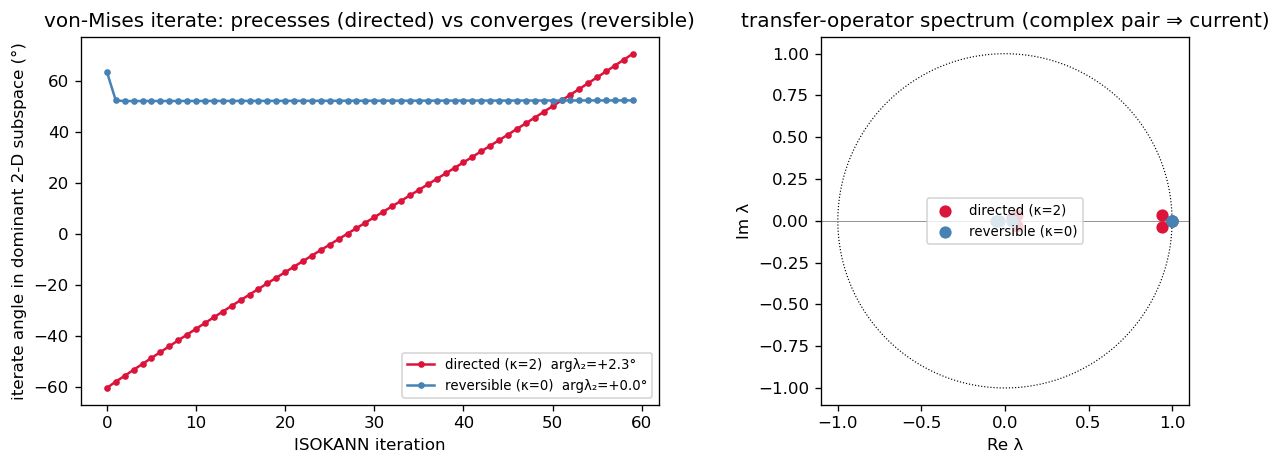

In [13]:
import theory_demo as thd
rows = ["| ring | dominant λ₂ | rate ε=logλ/τ | iterate rotation/iter | verdict |",
        "|---|---|---|---|---|"]
for rev, name in [(False, "directed (κ=2)"), (True, "reversible (κ=0)")]:
    T, _ = thd.angular_transfer_operator(reversible=rev)
    ang, frac, w = thd.iterate_angle(T)
    lam = w[1]; tau = 250 * 2e-3; eps = np.log(lam) / tau
    dd = np.diff(ang); dd = (dd + 180) % 360 - 180; rot = float(np.mean(dd[-30:]))
    rows.append(f"| {name} | {lam.real:.3f}{lam.imag:+.3f}i | {eps.real:+.3f}{eps.imag:+.3f}i "
                f"| {rot:+.2f}° | {'**precesses** (no fixed real χ)' if abs(rot) > 1 else 'converges'} |")
display(Markdown("\n".join(rows)))
thd.make_figure("figures/theory_rotation.png")
display(Image("figures/theory_rotation.png"))

**Corollary (what ISOKANN sees, and what it cannot).**
At $k=\dim V$ ISOKANN converges to the **real PCCA+ memberships directly from the lagged pairs,
without ever forming $v,\bar v$.** Choosing $k$ *where the network stabilizes* is exactly the
condition $k=\dim V$: a bisecting $k$ precesses and never stabilizes, so the empirical $k$-sweep
performs GPCCA's *feasible-$k$* test **in real arithmetic, without computing an eigenvalue.** The
non-reversibility is **invisible in $\chi$** (it keeps $|\lambda|=r$, discards $\theta$, so
$\Delta F=-\tfrac1\beta\ln(\varepsilon_2/\varepsilon_1)$ would see only $\operatorname{Re}\varepsilon$);
it is recovered only as the complex eigenvalue of the reduced $k\times k$ Koopman matrix
$\widehat K_{ij}=\langle\chi_i,\,K^\tau\chi_j\rangle$ in the learned basis — the post-hoc
$\operatorname{Im}\lambda$ readout.

**This proves out in the numbers.** Plain ISA at $k=3$ on the directed ring is **AUROC $0.997\pm0.000$**
— a stable real fixed point (Proposition, case $k=\dim V$) — while the $k=2$-like 1-D iteration
**precesses by $\arg\lambda_2$** per step (table and figure above, case $k<\dim V$). The two together
are the empirical proof of the $k$-dependence.

**Net positioning.** ISA + ISOKANN at the correct $k$ is the tool for the memberships and sidesteps the
eigenfunctions entirely; the feasibility projection is *optional* — it only matters if $\chi$ must be a
probability partition, and no triangle tiles a circle (hence the negative "memberships" for transition
states). The durable residue of the non-reversible analysis is therefore not a new training *target*
but the post-hoc $\operatorname{Im}\lambda$ **diagnostic** that recovers the current the real $\chi$
discards.

> **Claim (paper form).** *ISOKANN computes the real PCCA+ membership directly from time-lagged pairs,
> and at the correct number of macrostates it converges without ever forming the (complex)
> eigenfunctions PCCA+ passes through; non-reversibility then appears only as a complex eigenvalue of
> the reduced Koopman matrix in the learned basis — never as a complex function.*